## Анализ эффективности внедрения методов снижения дисперсии в А/В-тестировании

Набор данных содержит историю событий пользователей интернет-магазина косметики за период с 10.2019 по 02.2020.

Продуктовая воронка: view -> card -> purchase.

Проведены очистка данных, разведочный анализ данных. Также выполнена симуляция А/В-теста сроком 4 недели на данных за 02.2020. Целевая метрика - E2E CR, вычисляемая по формуле $\frac{\text{Total purchases}}{\text{Total views}}\cdot 100\%$.

Внедряются методы снижения дисперсии:
1. CUPED. В качестве ковариаты используется целевая метрика за предпериод.
2. Постстратификация. Пользователи разделяются на страты в зависимости от активности.

Сравниваются дисперсии оценок для каждого подхода. Показано, насколько постстратификация и CUPED повышают чувствительность теста по сравнению с базовой версией и расчитывается на сколько теоретически меньше можно держать эксперимент.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import kagglehub
import hashlib
import ipywidgets as widgets
from IPython.display import display


for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/2019-Nov.csv
/kaggle/input/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/2020-Feb.csv
/kaggle/input/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/2019-Oct.csv
/kaggle/input/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/2019-Dec.csv
/kaggle/input/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/2020-Jan.csv


In [3]:
sns.set_theme(style='dark')
sns.color_palette('cubehelix')
cubehelix_cmap = sns.cubehelix_palette(start=0.5, rot=-0.5, as_cmap=True, dark=0.2, light=0.9)

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'figure.figsize': (16, 8),
    'lines.linewidth': 2.5,
    'lines.markersize': 8,
    'font.family': 'sans-serif',
    'axes.prop_cycle': plt.cycler(color=sns.color_palette('cubehelix', 8))
})

In [4]:
files = {
    '2019-Oct': '/kaggle/input/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/2019-Oct.csv',
    '2019-Nov': '/kaggle/input/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/2019-Nov.csv',
    '2019-Dec': '/kaggle/input/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/2019-Dec.csv',
    '2020-Jan': '/kaggle/input/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/2020-Jan.csv',
    '2020-Feb': '/kaggle/input/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/2020-Feb.csv',
}

dataframes = {name: pd.read_csv(path) for name, path in files.items()}

### Анализ пропусков и аномалий в данных

In [5]:
out_tabs = []
tab_titles = []

for name, df in dataframes.items():
    tab_titles.append(name)
    out = widgets.Output()
    
    with out:
        df.info()
        display(df.describe(include='all'))
        display(df.isna().sum())
        
    out_tabs.append(out)

tabs = widgets.Tab(children=out_tabs)
for i, title in enumerate(tab_titles):
    tabs.set_title(i, title)

display(tabs)

In [6]:
for name, df in dataframes.items():
    print(name)
    display(df[df['price'] < 0]['event_type'].value_counts())

2019-Oct


event_type
purchase    20
Name: count, dtype: int64

2019-Nov


event_type
purchase    17
Name: count, dtype: int64

2019-Dec


event_type
purchase    18
Name: count, dtype: int64

2020-Jan


event_type
purchase            36
view                 2
remove_from_cart     1
Name: count, dtype: int64

2020-Feb


event_type
purchase            35
remove_from_cart     2
Name: count, dtype: int64

Базовое знакомство с данными выявило ряд аномалий: отрицательные цены товаров и пропущенные значения пользовательских сессий. 
Отрицательные цены встречаются не только в событии 'purchase', поэтому нельзя сказать, что это - возвраты пользователей. Вероятнее, это ошибки логирования и такие записи (131) из дальнейшего анализа будут удалены, также как и записи, где в столбце 'user_session' null-значения. 

In [7]:
for name, df in dataframes.items():
    df['event_time'] = pd.to_datetime(df['event_time'], utc=True)
    dataframes[name] = df[(df['price'] >= 0) & (df['user_session'].notna())]

### Активность пользователей

In [8]:
order = ['view', 'cart', 'remove_from_cart', 'purchase']
share_events = pd.concat(
    [df['event_type'].value_counts(normalize=True).mul(100).round(2).rename(name) for name, df in dataframes.items()]
    , axis=1).reindex(order)

display(share_events)

,2019-Oct,2019-Nov,2019-Dec,2020-Jan,2020-Feb
event_type,,,,,
view,45.40,44.79,48.93,47.79,47.01
cart,30.03,28.29,26.23,26.91,27.62
remove_from_cart,18.58,19.96,18.81,19.11,19.55
purchase,5.99,6.96,6.03,6.19,5.82


Удаление из корзины имеет достаточно высокую долю. В дальнейшем анализе событие "удаление из корзины" не будет рассматриваться, но можно предположить, что такие показатели могут быть вызваны:
1. поведенческим паттерном, т.е. пользователи сначала добавляют в корзину все понравившиеся товары, а потом выбирают что нужнее или же отсутствует вкладка "избранное" и корзина используется вместо нее;
2. при скроллинге происходит куча мисс-кликов и пользователи случайно добавляют товары в корзину, потом их приходится удалять;
3. сравнением нескольких схожих товаров и выбор одного из них в корзине;

В целом доли всех событий стабильны, кроме добавления в корзину, которая имеет спад к зиме 2020.

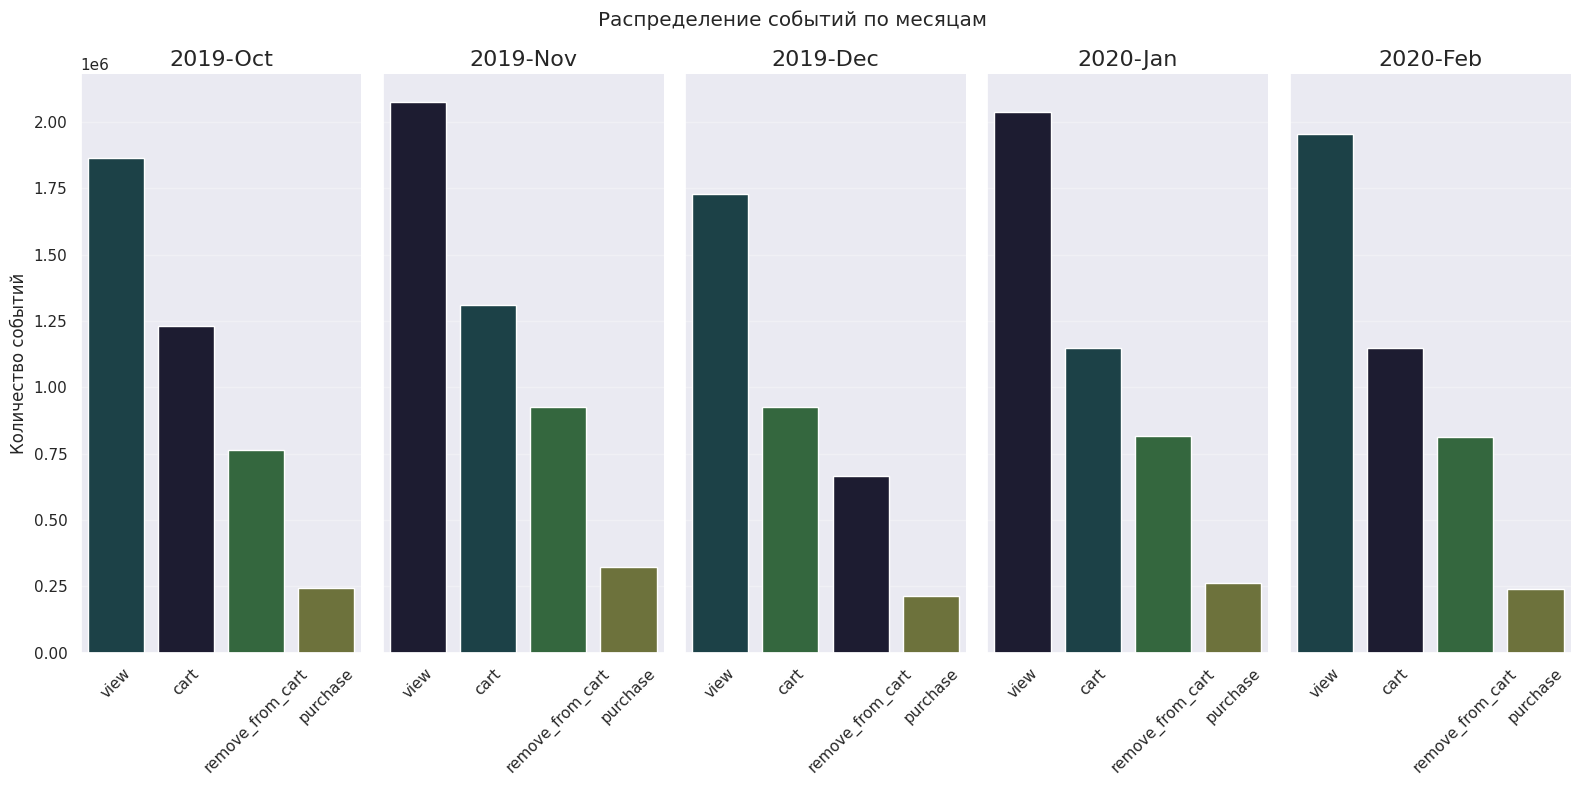

In [9]:
fig, axes = plt.subplots(1, len(dataframes), sharey=True)
fig.suptitle('Распределение событий по месяцам')

for ax, (name, df) in zip(axes, dataframes.items()):
    sns.countplot(data=df, x="event_type", order=order, ax=ax, hue="event_type", legend=False)
    ax.set_title(name)
    ax.set_xlabel('')
    ax.set_ylabel('Количество событий')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Наблюдается увеличение количества событий в ноябре, связанный, скорее всего, с Black Friday. В предновогодние праздники, однако, пользователи стали менее активными, что может говорить о том, что пользователи не заинтересованы в товарах перед праздниками. После Нового года активность снова вышла на стабильный уровень, немного увеличившись относительно прошлого года. 

Посмотрим детальнее по дням на уникальных пользователей, общее число событий и количество покупок во всем рассматриваемом периоде.

In [10]:
df_all = pd.concat(dataframes.values(), ignore_index=True)
df_all['date'] = df_all['event_time'].dt.normalize()

daily = df_all.groupby('date', as_index=False).agg(
    events=('event_type', 'count'),
    users=('user_id', 'nunique'),
    purchases=('event_type', lambda x: (x == 'purchase').sum()))

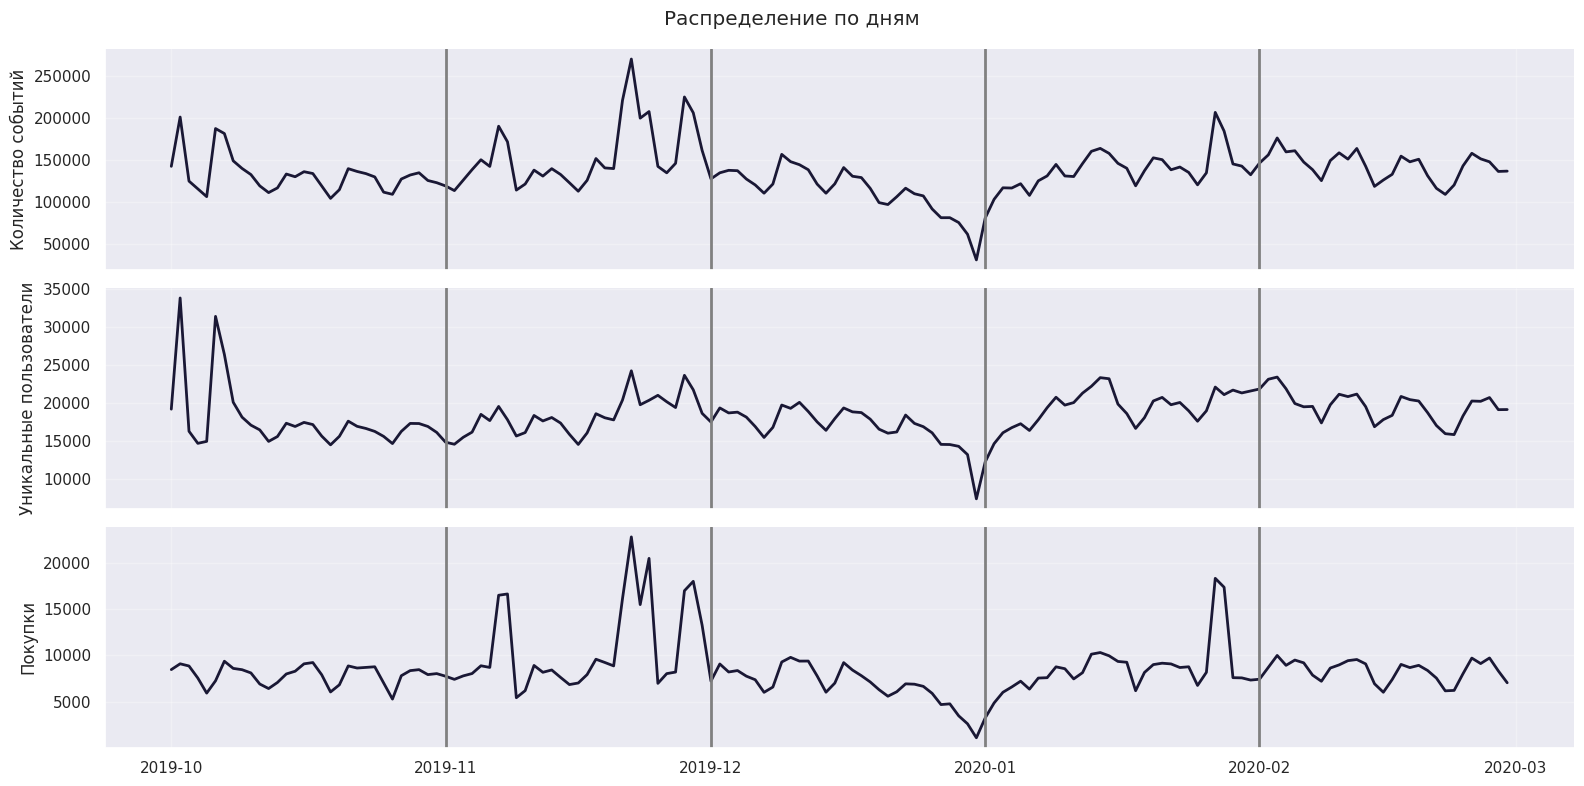

In [11]:
data_list = [
    ('events', 'Количество событий'),
    ('users', 'Уникальные пользователи'),
    ('purchases', 'Покупки')
]

fig, axes = plt.subplots(3, 1, sharex=True)
fig.suptitle('Распределение по дням')

for i, (col, ylabel) in enumerate(data_list):
    sns.lineplot(data=daily, x='date', y=col, ax=axes[i], linewidth=2)
    axes[i].set_ylabel(ylabel)
    axes[i].set_xlabel('')
    
    for month_start in pd.date_range('2019-11-01', '2020-02-01', freq='MS', tz='UTC'):
        axes[i].axvline(month_start, color='gray', linestyle='-', linewidth=2)

plt.tight_layout()
plt.show()

Здесь мы также можем наблюдать общий тренд увеличения активности в ноябре, ее постепенное затухание до минимума к новогодним праздникам и новый всплеск в конце января. В феврале все показатели стабилизируются, несмотря на некую волатильность присущую ежедневным колебаниям. 

Интересен пик в октябре по уникальным пользователям. Можно предположить, что интернет-магазин привлек новую аудиторию, тем самым увеличив количество событий в октябре. Постепенно активность новых пользователей стабилизировалось до наступления пиков ноября. 

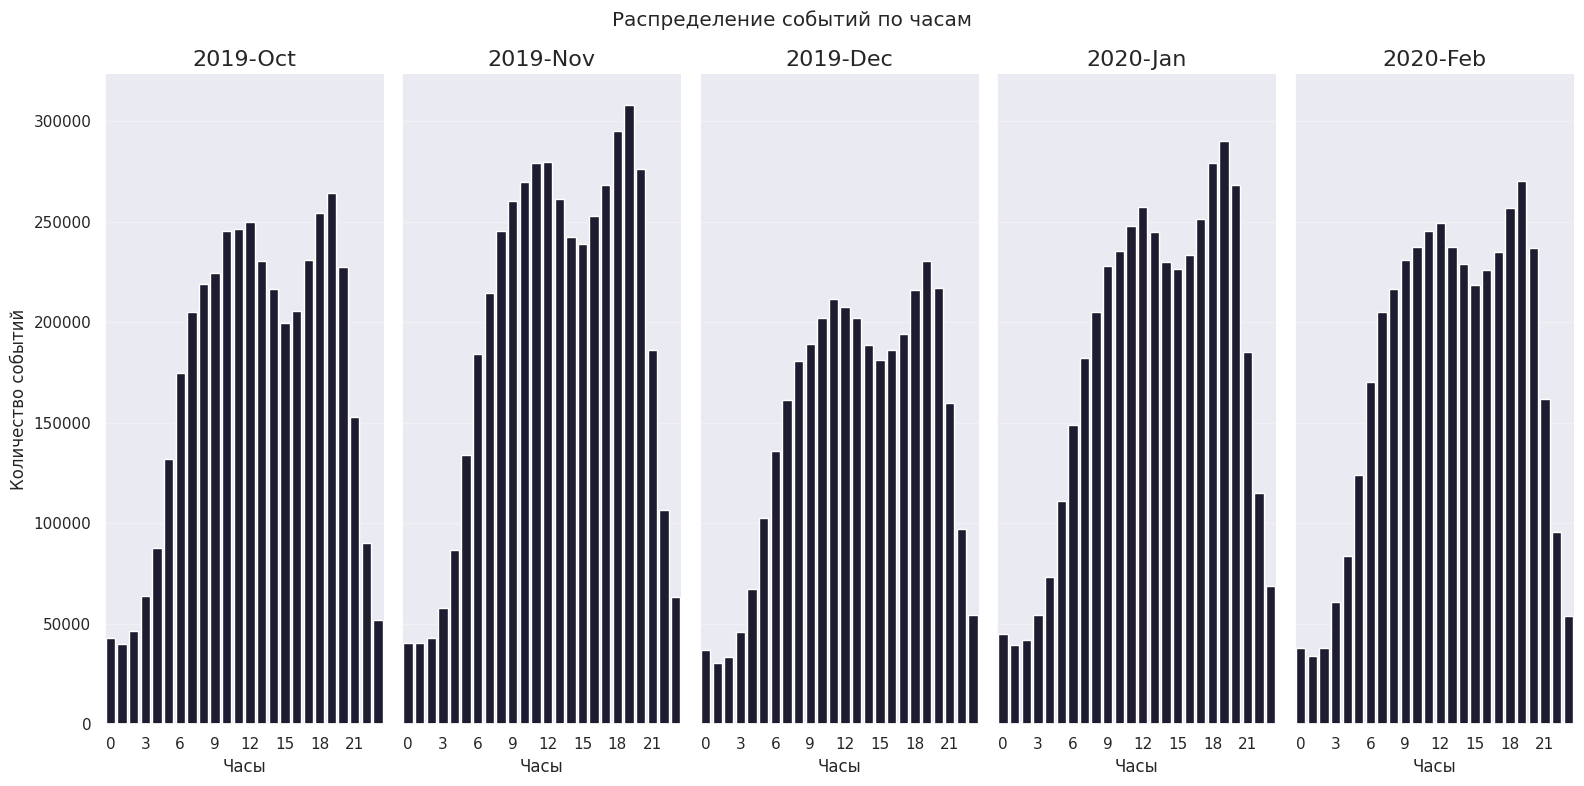

In [13]:
fig, axes = plt.subplots(1, len(dataframes), sharey=True)
fig.suptitle('Распределение событий по часам')

for ax, (name, df) in zip(axes, dataframes.items()):
    sns.countplot(x=df['event_time'].dt.hour, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Часы')
    ax.set_xticks(range(0, 24, 3))

axes[0].set_ylabel('Количество событий')
plt.tight_layout()
plt.show()

Для каждого месяца график распределения событий по часам показывает ярко выраженный бимодальный характер с пиками в 13 и 19 часов. 
Пользователи заходят в обеденное время и после работы в интернет-магазин для выбора товаров. Это поведение пользователей можно считать обычным, без каких-либо особенностей.

In [15]:
seen_users = set()
months, total, new, returning = [], [], [], []

for name, df in dataframes.items():
    current_users = set(df['user_id'].unique())
    new_users = current_users - seen_users
    ret_users = current_users & seen_users

    months.append(name)
    total.append(len(current_users))
    new.append(len(new_users))
    returning.append(len(ret_users))

    seen_users |= current_users

user_dynamics = pd.DataFrame({
    'month': months,
    'total': total,
    'new': new,
    'returning': returning
})

user_dynamics['returning_pct'] = (user_dynamics['returning'] / user_dynamics['total'] * 100).round(2)
display(user_dynamics)

,month,total,new,returning,returning_pct
0,2019-Oct,399634,399634,0,0.00
1,2019-Nov,368183,313391,54792,14.88
2,2019-Dec,370108,299420,70688,19.10
3,2020-Jan,410018,328892,81126,19.79
4,2020-Feb,391005,297814,93191,23.83


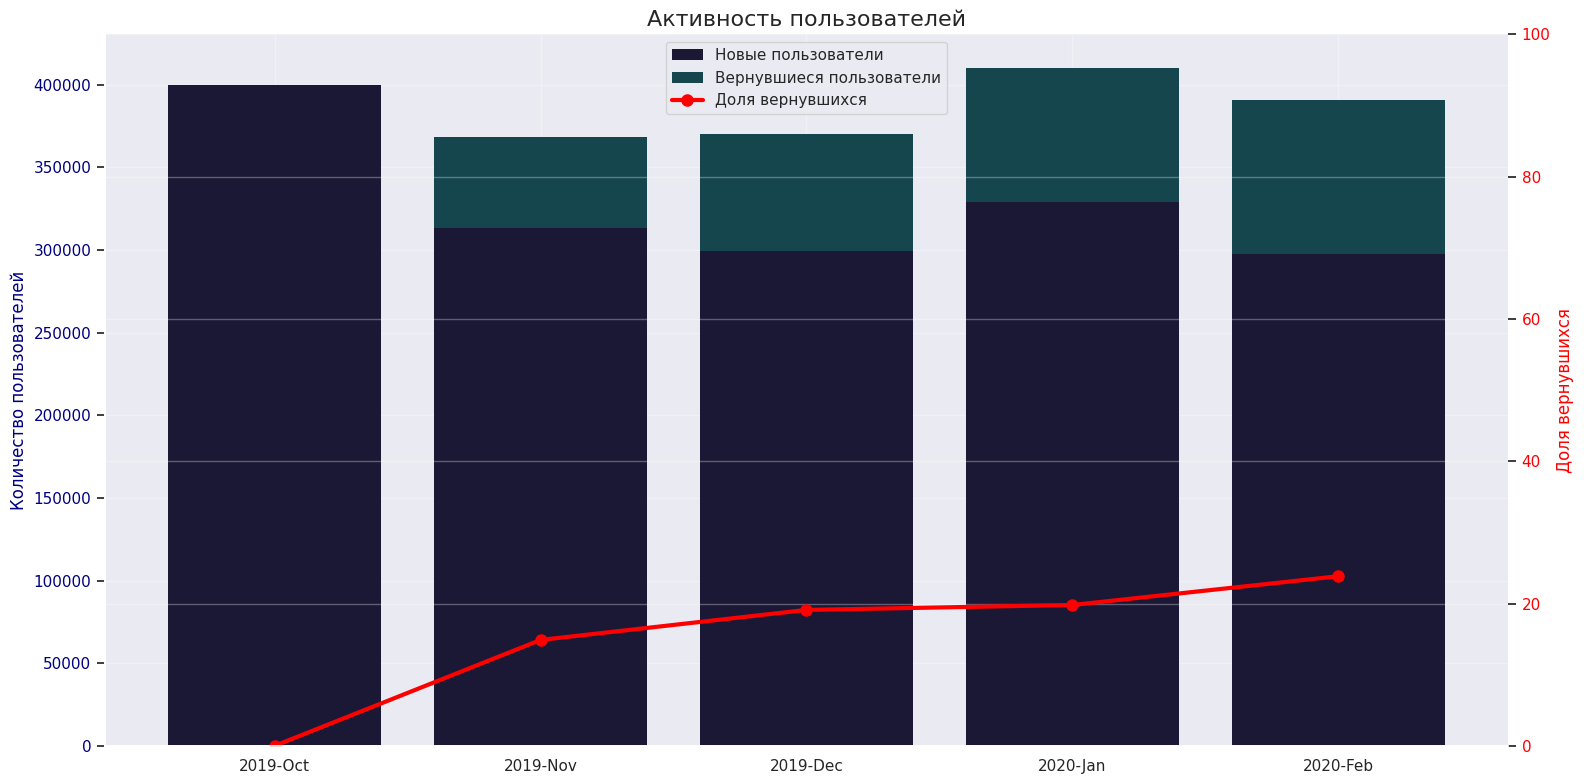

In [17]:
x = range(len(user_dynamics['month']))
fig, ax1 = plt.subplots()
ax1.bar(x, user_dynamics['new'], label='Новые пользователи', linewidth=0)
ax1.bar(x, user_dynamics['returning'], bottom=user_dynamics['new'], label='Вернувшиеся пользователи', linewidth=0)

ax1.set_ylabel('Количество пользователей', color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.set_xticks(x)
ax1.set_xticklabels(user_dynamics['month'])

ax2 = ax1.twinx()
ax2.plot(x, user_dynamics['returning_pct'], color='red', marker='o', 
         linewidth=3, label='Доля вернувшихся')

ax2.set_ylabel('Доля вернувшихся', color='red')
ax2.set_ylim(0, 100)
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title('Активность пользователей')
plt.tight_layout()
plt.show()

Приток новых пользователей высокий и стабильный, но общее количество пользователей в месяц остается примерно на одном уровне, что говорит о высоком оттоке пользователей. Retention постепенно увеличивается с 15 до 23;. Но важно отметить, что это накопленный показатель.  

### Продуктовая воронка

In [18]:
results = []

for name, df in dataframes.items():
    pivot = df.pivot_table(index='user_id', columns='event_type', aggfunc='size', fill_value=0) > 0
    
    cnt_viewed = pivot['view'].sum()
    cnt_carted = pivot['cart'].sum()
    
    view_and_cart = (pivot['view'] & pivot['cart']).sum()
    cart_and_purchase = (pivot['cart'] & pivot['purchase']).sum()
    view_and_purchase = (pivot['view'] & pivot['purchase']).sum()
    
    results.append({
        'month': name,
        'view-cart': round(view_and_cart / cnt_viewed * 100, 2),
        'cart-purchase': round(cart_and_purchase / cnt_carted * 100, 2),
        'view-purchase': round(view_and_purchase / cnt_viewed * 100, 2),
        'active_users': len(pivot)
    })

cr_on_steps = pd.DataFrame(results).set_index('month')
display(cr_on_steps)

,view-cart,cart-purchase,view-purchase,active_users
month,,,,
2019-Oct,31.72,19.01,6.21,399634
2019-Nov,23.67,32.45,8.36,368183
2019-Dec,20.17,30.34,6.67,370108
2020-Jan,20.38,30.12,6.65,410018
2020-Feb,20.62,28.45,6.38,391005


In [21]:
funnel_cols = ['view-cart', 'cart-purchase', 'view-purchase']

df_funnel = (
    cr_on_steps[funnel_cols]
    .reset_index()
    .melt(id_vars='month', var_name='step', value_name='cr')
)

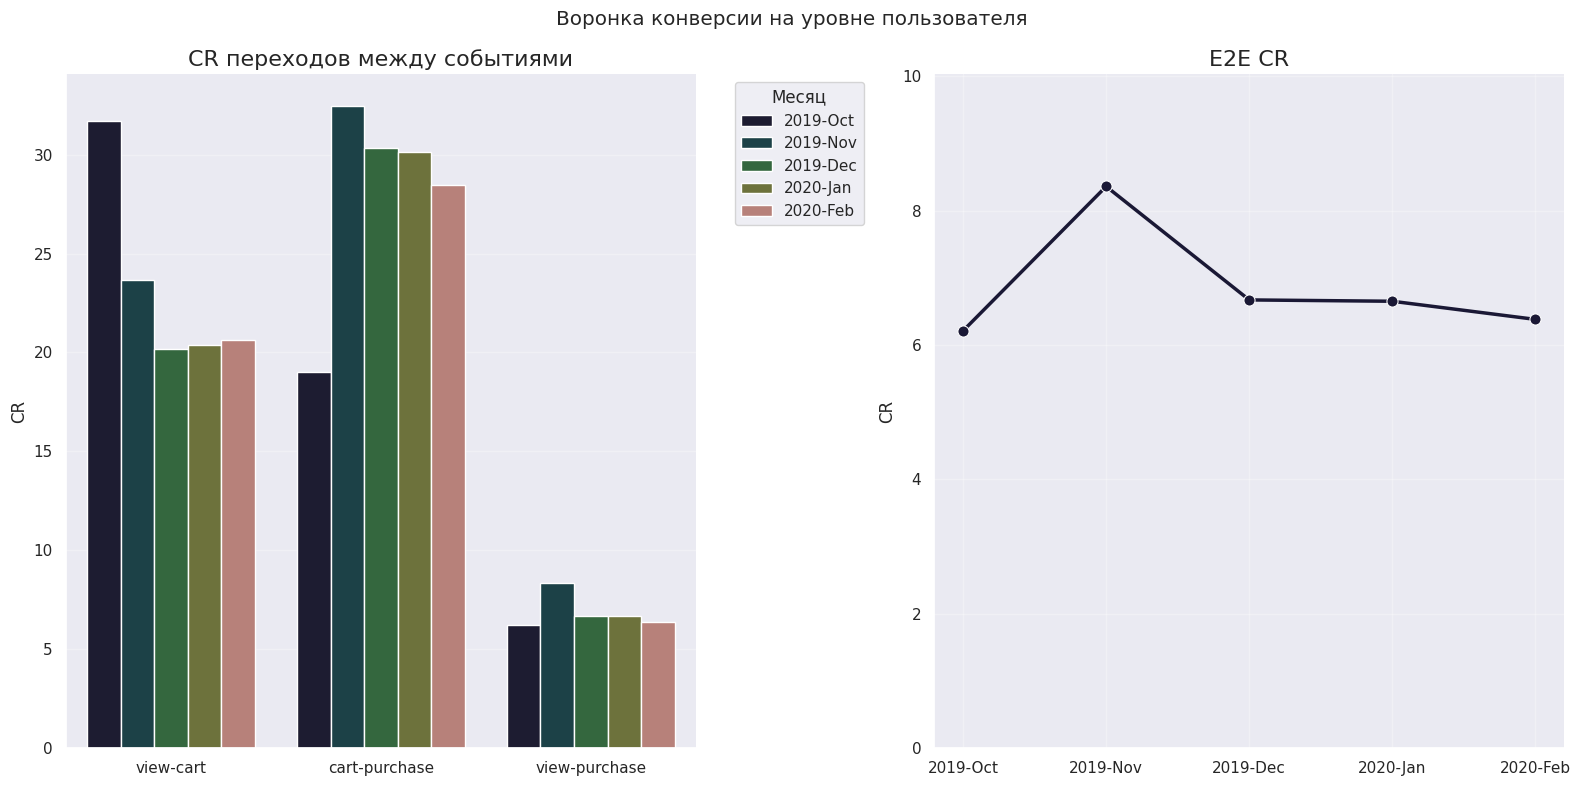

In [22]:
fig, axes = plt.subplots(1, 2)
fig.suptitle('Воронка конверсии на уровне пользователя')

sns.barplot(data=df_funnel, x='step', y='cr', hue='month', ax=axes[0])
axes[0].set_title('CR переходов между событиями')
axes[0].set_ylabel('CR')
axes[0].set_xlabel('')
axes[0].legend(title='Месяц', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.lineplot(data=cr_on_steps, x=cr_on_steps.index, y='view-purchase', marker='o', linewidth=2.5, ax=axes[1])
axes[1].set_title('E2E CR')
axes[1].set_ylabel('CR')
axes[1].set_xlabel('')
axes[1].set_ylim(0, cr_on_steps['view-purchase'].max() * 1.2)

plt.tight_layout()
plt.show()

На левом графике видно снижение конверсии из просмотров в корзину после октября 2019. Возможно, изменился дизайн карточки товара, привлекаются люди не заинтересованные в товаре или изменился расчет события 'cart'. Из корзины в покупку наблюдается наоборот рост следующих за октябрем периодами, даже несмотря на пик ноября, носящий сезонный характер. 

E2E CR остается стабильной на всем периоде, кроме ноября. Как уже было отмечено, в ноябре скорее всего наблюдался сезонный эффект, однако важно заметить, что интернет-магазин также мог простимулировать спрос на свои товары, привлекая клиентов скидками и промо-акциями. 

In [23]:
statistics = {}

for name, df in dataframes.items():
    purchases_per_user = (
        df[df['event_type'] == 'purchase']
        .groupby('user_id')['event_type']
        .count()
        .reindex(df['user_id'].unique(), fill_value=0)
    )
    
    statistics[name] = purchases_per_user.describe().round(2)
    
display(pd.DataFrame(statistics))

,2019-Oct,2019-Nov,2019-Dec,2020-Jan,2020-Feb
count,399634.00,368183.00,370108.00,410018.00,391005.00
mean,0.61,0.88,0.58,0.64,0.62
std,3.71,4.57,3.53,3.82,4.03
min,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00
75%,0.00,0.00,0.00,0.00,0.00
max,329.00,438.00,399.00,263.00,461.00


Здесь можно наблюдать, что более 75% пользователей не совершают ни одной покупки и есть покупали с аномально большим количеством покупок. 

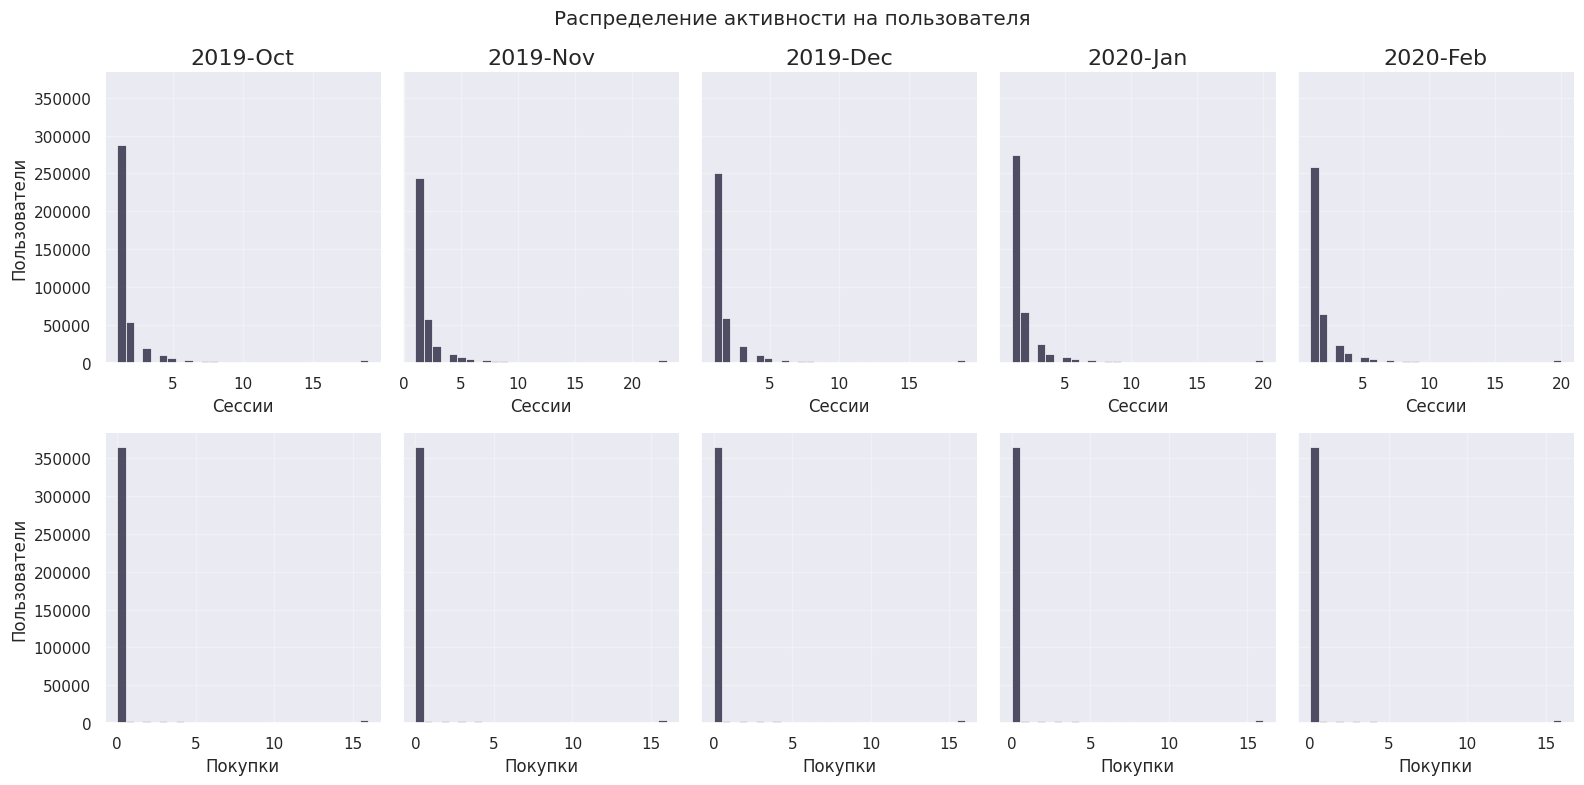

In [24]:
fig, axes = plt.subplots(2, len(dataframes), sharey=True)
fig.suptitle('Распределение активности на пользователя')

for i, (name, df) in enumerate(dataframes.items()):
    sessions_per_user = df.groupby('user_id')['user_session'].nunique()
    clip_sessions = sessions_per_user.clip(upper=sessions_per_user.quantile(0.99))
    
    sns.histplot(clip_sessions, bins=30, ax=axes[0][i])
    axes[0][i].set_title(name)
    axes[0][i].set_xlabel('Сессии')
    if i == 0:
        axes[0][i].set_ylabel('Пользователи')

    clip_purchases = purchases_per_user.clip(upper=purchases_per_user.quantile(0.99))
    sns.histplot(clip_purchases, bins=30, ax=axes[1][i])
    axes[1][i].set_xlabel('Покупки')
    if i == 0:
        axes[1][i].set_ylabel('Пользователи')

plt.tight_layout()
plt.show()

In [25]:
avg_check = {}
df_purchases = df_all[df_all['event_type'] == 'purchase']

top_cats = (df_purchases['category_code']
            .dropna()
            .value_counts()
            .head(10)
            .sort_values(ascending=False))

top_brands = (df_purchases['brand']
              .dropna()
              .value_counts()
              .head(10)
              .sort_values(ascending=False))

price_clip = df_purchases['price'].clip(upper=df_purchases['price'].quantile(0.99))

for name, df in dataframes.items():
    avg_check[name] = (df[df['event_type'] == 'purchase']
                       .groupby('user_session')['price']
                       .sum()
                       .mean())
    
avg_check_df = pd.Series(avg_check).reset_index()
avg_check_df.columns = ['month', 'avg_check']

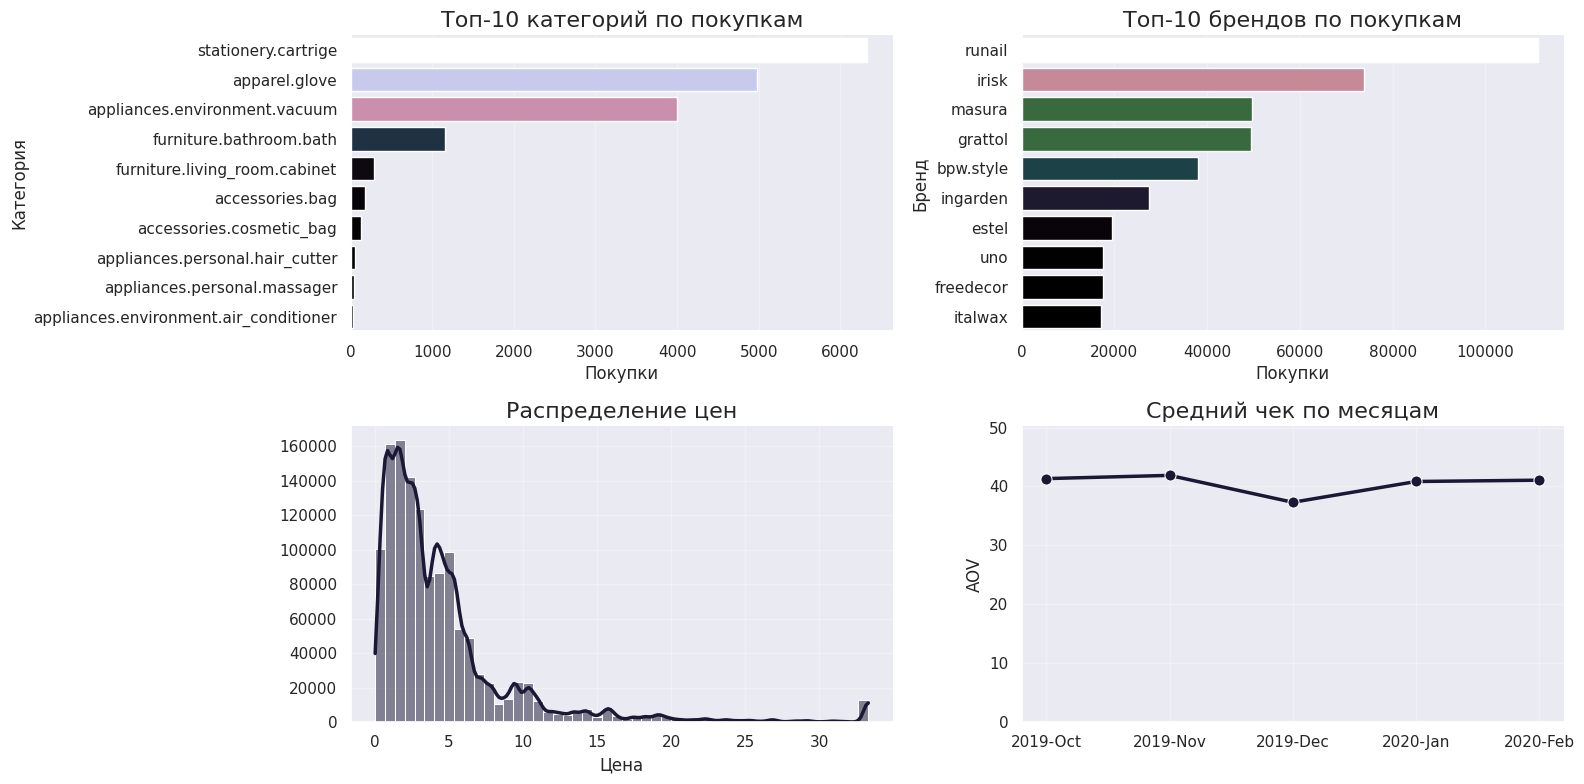

In [43]:
fig, axes = plt.subplots(2, 2)

sns.barplot(x=top_cats.values, y=top_cats.index, hue=top_cats.values, legend=False, ax=axes[0][0])
axes[0][0].set_title('Топ-10 категорий по покупкам')
axes[0][0].set_ylabel('Категория')
axes[0][0].set_xlabel('Покупки')

sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.values, legend=False, ax=axes[0][1])
axes[0][1].set_title('Топ-10 брендов по покупкам')
axes[0][1].set_ylabel('Бренд')
axes[0][1].set_xlabel('Покупки')

sns.histplot(price_clip, bins=50, kde=True, ax=axes[1][0])
axes[1][0].set_title('Распределение цен')
axes[1][0].set_ylabel('')
axes[1][0].set_xlabel('Цена')

sns.lineplot(data=avg_check_df, x='month', y='avg_check', marker='o', ax=axes[1][1])
axes[1][1].set_title('Средний чек по месяцам')
axes[1][1].set_xlabel('')
axes[1][1].set_ylabel('AOV')
axes[1][1].set_ylim(0, avg_check_df['avg_check'].max() * 1.2)

plt.tight_layout()
plt.show()

Средний чек от месяца к месяцу остается стабильным с небольшой просадкой в декабре, что связано с активностью покупок пользователей в целом, как было замечено на прошлых графиках.

Распределение цен до 99 перцентиля показало, что большинство товаров имеют небольшую стоимость. Топ категорий по покупкам подтверждают эти данные, так как чаще всего покупают канцелярские картриджи, перчатки, косметички и сумки для аксессуаров. Есть небольшая странность, что в интернет-магазине косметики чаще всего покупают именно канцелярские картриджи. Возможно, компания расширяет свой ассортимент и на другие сегменты товаров или товары некорректно классифицируются системой.

В топе брендов находятся все русские производители, что может говорить о том, что интернет-магазин находится в России и/или акцентирован на русских покупателей. Скорее всгео интернет-магазин - нишевый маркетплейс для профессионалов в бьюти-сфере. Товары имеют низкую цену, так как продаются в большинстве своем расходники и максимумы по числу покупок соответствуют оптовым закупкам товаров.

In [27]:
df_jan_feb = df_all[df_all['event_time'] >= '2020-01-01']

df_jan_feb['month'] = df_jan_feb['event_time'].dt.to_period('M').astype(str)
df_jan_feb['week'] = df_jan_feb['event_time'].dt.isocalendar().week.astype(int)

weekly_pivot = df_jan_feb.pivot_table(index=['month', 'week', 'user_id'], columns='event_type', aggfunc='size', fill_value=0) > 0
e2e_weekly = weekly_pivot.assign(
    in_funnel = weekly_pivot['view'],
    converted = weekly_pivot['view'] & weekly_pivot['purchase']
)
res_e2e = e2e_weekly.groupby(['month', 'week']).apply(
    lambda x: (x['converted'].sum() / x['in_funnel'].sum() * 100)
)

/tmp/ipykernel_614/1390000360.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_jan_feb['month'] = df_jan_feb['event_time'].dt.to_period('M').astype(str)
/tmp/ipykernel_614/1390000360.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_jan_feb['month'] = df_jan_feb['event_time'].dt.to_period('M').astype(str)
/tmp/ipykernel_614/1390000360.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_jan_feb['week'] = df_jan_feb['event_time'].dt.isocalendar().w

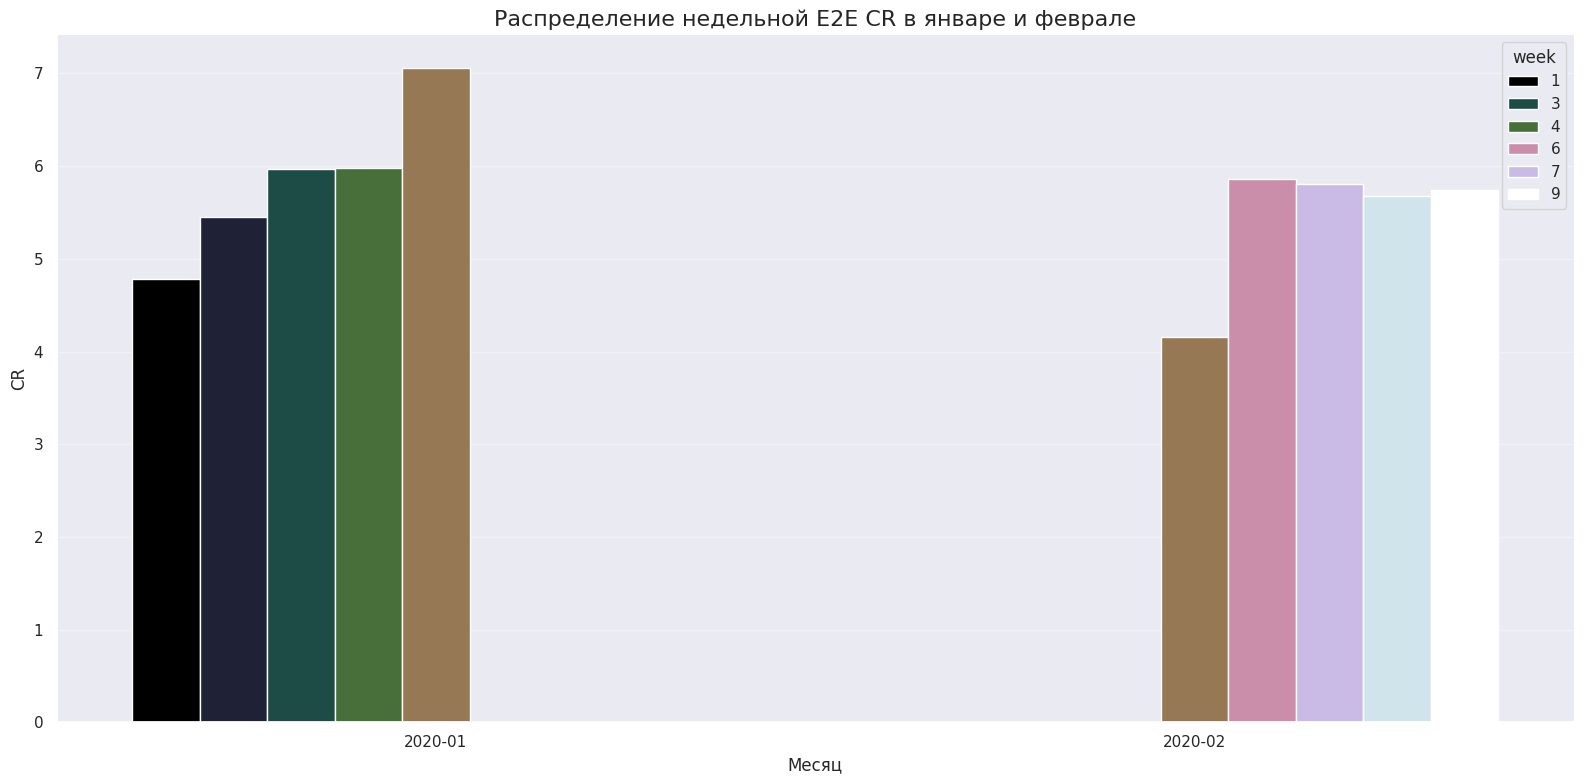

In [41]:
sns.barplot(data=res_e2e.reset_index(name='conversion'), x='month', y='conversion', hue='week')
plt.title('Распределение недельной E2E CR в январе и феврале')
plt.ylabel('CR')
plt.xlabel('Месяц')
plt.tight_layout()
plt.show()

Конверсия в январе постепенно повышается от начала месяца к концу, связано с увеличением активности пользователей. На пятой неделе 2020 года 5 дней были январские и только 2 - фервальские. Этим объясняется низкая конверсия первой недели февраля и высокая конверсия последней недели января. Видимо, в этот период пользователи чаще покупали именно в будние дни, а активность в выходные упала. 

В дальнейшие недели февраля конверсия была стабильной, поэтому для симуляции эксперимента будет использоваться именно февральский период.

### Пользовательские паттерны

In [29]:
def user_metrics(df):
    purchases = df[df['event_type'] == 'purchase'].groupby('user_id')['event_type'].count().rename('purchases')
    views = df[df['event_type'] == 'view'].groupby('user_id')['event_type'].count().rename('views')
    sessions = df.groupby('user_id')['user_session'].nunique().rename('sessions')
    revenue = df[df['event_type'] == 'purchase'].groupby('user_id')['price'].sum().rename('revenue')
    
    return pd.concat([purchases, views, sessions, revenue], axis=1).fillna(0)

In [30]:
def metric_stability(dataframes):
    month_names = list(dataframes.keys())
    metrics = ['purchases', 'views', 'sessions', 'revenue']

    u_metrs = {name: user_metrics(df) for name, df in dataframes.items()}
    corr_results = []
    
    for i in range(len(month_names) - 1):
        m1, m2 = month_names[i], month_names[i + 1]
        df1 = u_metrs[m1]
        df2 = u_metrs[m2]

        buyers1 = df1[df1['purchases'] > 0].index
        buyers2 = df2[df2['purchases'] > 0].index
        common_users = buyers1.intersection(buyers2)

        for metric in metrics:
            x = df1.loc[common_users, metric]
            y = df2.loc[common_users, metric]
            corr = x.corr(y)
            corr_results.append({
                'pair':   f'{m1}\n-{m2}',
                'metric': metric,
                'corr':   round(corr, 3),
                'n_users': len(common_users)
            })

    return pd.DataFrame(corr_results)

In [31]:
corr_df = metric_stability(dataframes)
corr_pivot = corr_df.pivot(index='metric', columns='pair', values='corr')

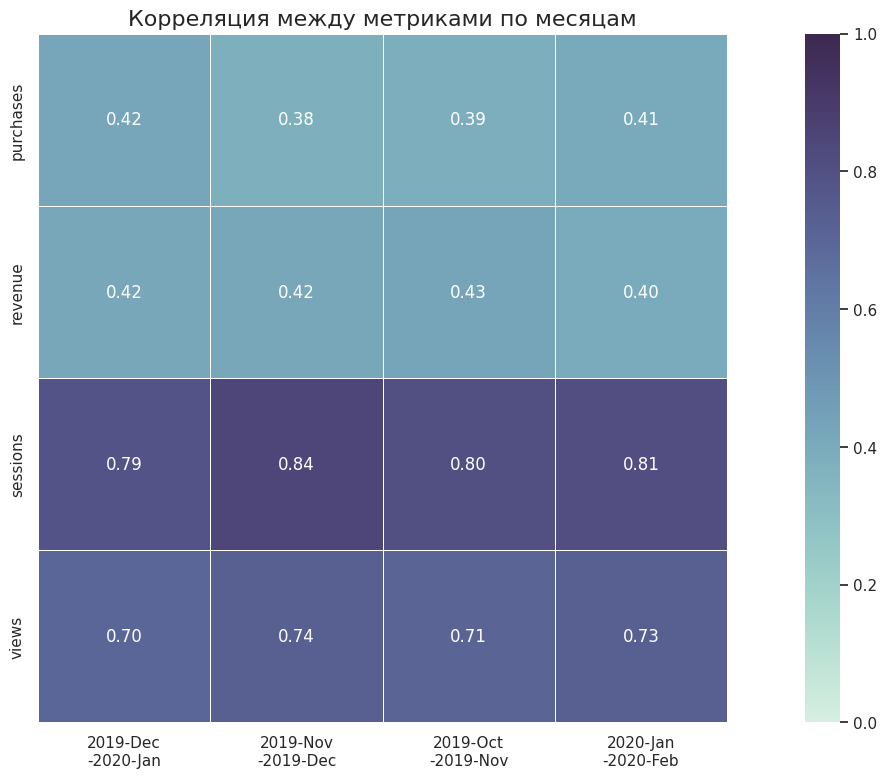

In [44]:
sns.heatmap(corr_pivot, annot=True, square=True, fmt='.2f', vmin=0, vmax=1, linewidth=.5, cmap=cubehelix_cmap)
plt.tight_layout()
plt.title('Корреляция между метриками по месяцам')
plt.ylabel('')
plt.xlabel('')
plt.show()

Анализ поведения пользователей показывает, что активные покупатели имеют стабильное поведение по сессиям и просмотрам товаров от месяца к месяцу. При этом выручка и покупки коррелируют слабее. Возможно, покупатели заходят проверить наличие скидки, новинки, а покупки совершают периодично/стратегически.

### Корреляция с целевой метрикой и разбиение на страты

In [45]:
df_jan = dataframes['2020-Jan']
jan_pivot = dataframes['2020-Jan'].pivot_table(index='user_id', columns='event_type', aggfunc='size', fill_value=0) > 0
feb_pivot = dataframes['2020-Feb'].pivot_table(index='user_id', columns='event_type', aggfunc='size', fill_value=0) > 0

feb_viewers = feb_pivot[feb_pivot['view']].index
jan_pivot = jan_pivot.reindex(feb_viewers, fill_value=False)
feb_pivot = feb_pivot.reindex(feb_viewers, fill_value=False)

converted_feb = (feb_pivot['view'] & feb_pivot['purchase']).astype(int).rename('converted_feb')
converted_jan = (jan_pivot['view'] & jan_pivot['purchase']).astype(int).rename('converted_jan')

jan_metrics = user_metrics(df_jan).reindex(feb_viewers, fill_value=0)
jan_metrics['converted_jan'] = converted_jan

df_combined = jan_metrics.copy()
df_combined['converted_feb'] = converted_feb

candidates = ['converted_jan', 'purchases', 'revenue', 'views', 'sessions']
corrs = df_combined[candidates + ['converted_feb']].corr()['converted_feb'].drop('converted_feb').sort_values(ascending=False)

display(corrs)

converted_jan    0.226629
revenue          0.183944
purchases        0.181935
views            0.120818
sessions         0.063330
Name: converted_feb, dtype: float64

Лучше всего с конверсией в феврале коррелирует конверсия в январе, как и можно было предположить. В качестве ковариаты для метода CUPED будет использована именно она.

In [46]:
top1_candidate = corrs.index[0]
covariate = df_combined[top1_candidate]

Также предусмотрим возможность разбиения пользователей на страты по количеству активных сессий в периоде. 

Такое разбиение - эвристический выбор, не аргументированный строго. Подразумевается, что количество сессий есть прокси активности пользователя и активные пользователи конвертируются иначе чем пассивные, поэтому страты по активности дают однородные группы внутри и разнородные между. 

Из результатов выше видно, что сессии слабее всего коррелируют с целевой метрикой, поэтому стратификация несильно уменьшит дисперсию. В дальнейшем предполагается попробовать страты по converted_jan. Страты по выручке и покупкам не анализировались из-за сильной скошенности распределения.

In [47]:
def assign_stratum(sessions):
    if sessions <=2:
        return 'low_active'
    elif sessions <= 4:
        return 'medium_active'
    else:
        return 'high_active'

In [50]:
df_combined['stratum'] = user_metrics(df_jan).reindex(feb_viewers, fill_value=0)['sessions'].apply(assign_stratum)

stratum_counts = df_combined['stratum'].value_counts().sort_index()

conv_by_stratum = (df_combined.groupby('stratum', as_index=False)['converted_feb']
                   .agg(users='count', buyers='sum')
                   .assign(conversion=lambda d: d['buyers'] / d['users'] * 100))

display(df_combined.groupby('stratum')[['purchases', 'views', 'sessions', 'revenue']].mean().round(2))

,purchases,views,sessions,revenue
stratum,,,,
high_active,5.79,41.09,15.37,26.59
low_active,0.06,0.35,0.13,0.30
medium_active,1.83,9.57,3.40,9.11


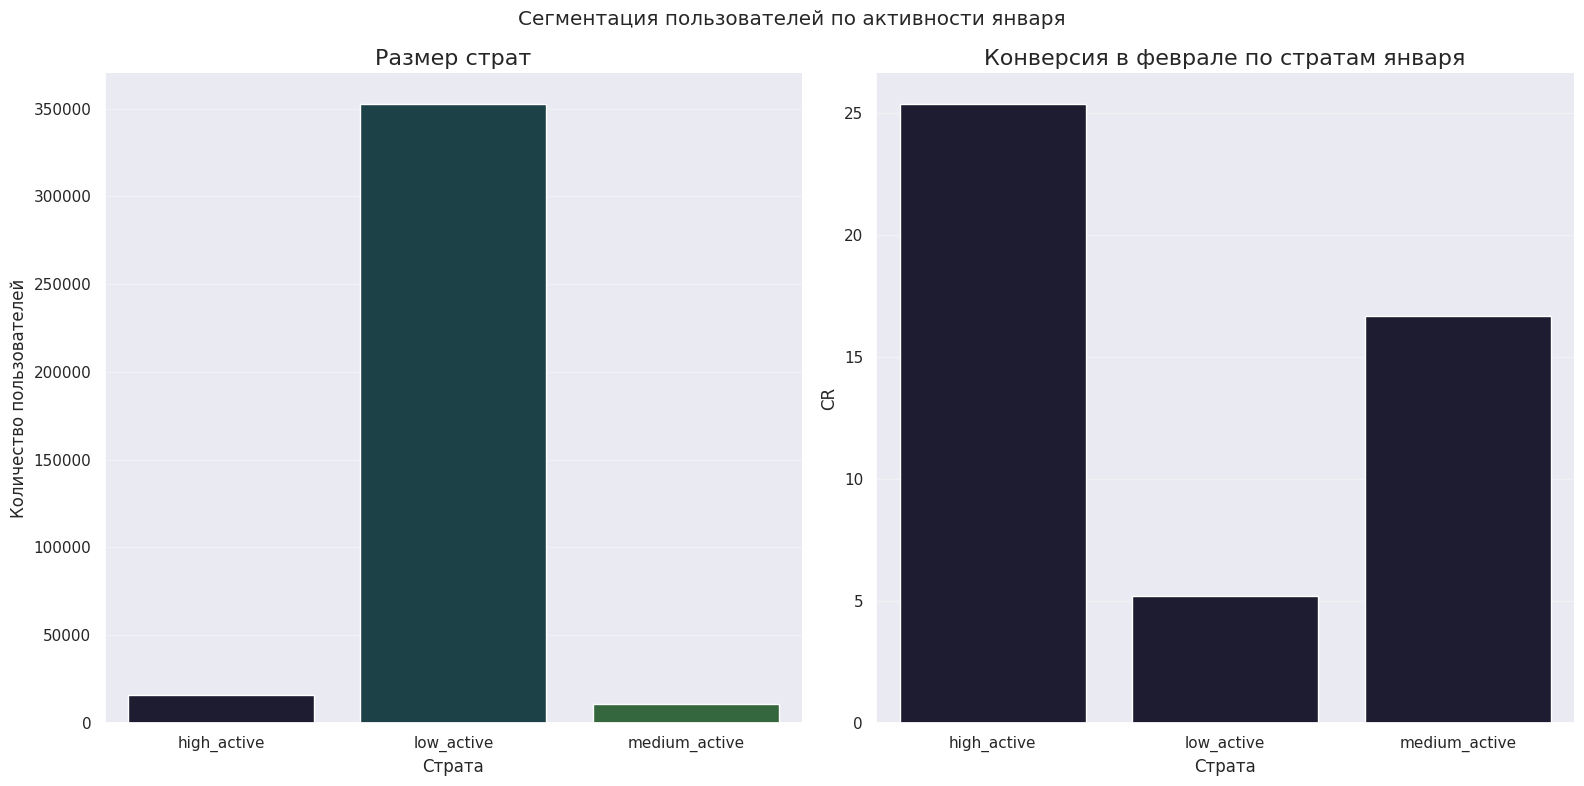

In [51]:
fig, axes = plt.subplots(1, 2)
fig.suptitle('Сегментация пользователей по активности января')

sns.barplot(x=stratum_counts.index, y=stratum_counts.values, hue=stratum_counts.index, legend=False, ax=axes[0])
axes[0].set_title('Размер страт')
axes[0].set_xlabel('Страта')
axes[0].set_ylabel('Количество пользователей')

sns.barplot(data=conv_by_stratum, x='stratum', y='conversion', ax=axes[1])
axes[1].set_title('Конверсия в феврале по стратам января')
axes[1].set_xlabel('Страта')
axes[1].set_ylabel('CR')

plt.tight_layout()
plt.show()

Гипотеза о том, что пользователи с большим количеством сессий конвертируются больше - подтвердилась исходя из данных графика (выше активность = выше конверсия). Страты отличаются по целевой метрике, поэтому мы можем рассчитывать на небольшое снижение дисперсии. Также можно заметить, что разбиение очень несбалансированное. Такой дисбаланс сильно ограничивает эффективность стратификации, так как при доминировании low_active над остальными стратами взвешенная оценка будет приближаться к простой и выигрыш в дисперсии будет минимален.

### Симуляция эксперимента

Здесь симулируется А/В-эксперимент по E2E CR с нулевой гипотезой $Н_0: CR_{control} = CR_{treatment}$ и альтернативой $Н_1: CR_{control} < CR_{treatment}$ на уровне статзначимости $\alpha = 0.05$ с использованием z-test для долей. 

Также показано, что возможно использование t-test для независимых выборок, так как на февральской выборке размером > 300k ЦПТ гарантирует нормальность выборочного среднего бинарной метрики, поэтому тесты асимптотически эквиваленты, что продемонстрировано в результатах - p-value для двух методов одинаковы как минимум до шестого знака. 

В эксперимент включаются только те пользователи, у которых в феврале было событие 'view', т.к. иначе пользователь не сконвертируется по воронке из 'view' в 'purchase'.

Рандомизация стратифицированная, внутри страты - независимая. Пользователи, которых не было в январе, получают страту 'new' и ковариату 0. Сплит 50/50. 

Внедряется синтетический эффект следующим образом: среди несконвертировавшихся из 'treatment' случайно выбирается  effect_size * len('treatment') пользователей и им присваивается конверсия 1.

In [53]:
def simulate_experiment(dataframes, user_metrics_pre, covariate, test_size=0.5, effect_size=0.0, random_seed=42):
    np.random.seed(random_seed)
    df_feb = dataframes['2020-Feb']

    feb_pivot = pd.pivot_table(df_feb, index='user_id', columns='event_type', aggfunc='size', fill_value=0) > 0
    all_feb_users = feb_pivot[feb_pivot['view']].index

    covariate_series = covariate.reindex(all_feb_users, fill_value=0)
    covariate_series.name = 'covariate'
    strata_pre = user_metrics_pre['stratum'].reindex(all_feb_users, fill_value='new')
    assignment = pd.Series(index=all_feb_users, dtype=str, name='group')

    for stratum, users_in_stratum in strata_pre.groupby(strata_pre):
        idx = users_in_stratum.index
        n_test = int(len(idx) * test_size)
        shuffled = np.random.permutation(idx)
        assignment[shuffled[:n_test]] = 'treatment'
        assignment[shuffled[n_test:]] = 'control'

    y = (feb_pivot.loc[all_feb_users, 'view'] & feb_pivot.loc[all_feb_users, 'purchase']).astype(int).rename('converted')

    if effect_size > 0:
        np.random.seed(random_seed + 1)
        treatment_users = assignment[assignment == 'treatment'].index
        not_converted = y.loc[treatment_users][y.loc[treatment_users] == 0].index.tolist()
        n_extra = int(len(treatment_users) * effect_size)
        extra_users = np.random.choice(not_converted, size=min(n_extra, len(not_converted)), replace=False)
        y.loc[extra_users] = 1

    experiment_df = pd.DataFrame({
        'user_id':    all_feb_users,
        'group':      assignment,
        'stratum':    strata_pre,
        'covariate':  covariate_series,
        'converted':  y,
    }).set_index('user_id')

    summary = (experiment_df
               .groupby('group')['converted']
               .agg(users='count', converted='sum')
               .assign(conversion=lambda d: (d['converted'] / d['users'] * 100).round(3)))

    return summary, experiment_df

In [54]:
def test_ttest(experiment_df):
    control = experiment_df[experiment_df['group'] == 'control']['converted']
    treatment = experiment_df[experiment_df['group'] == 'treatment']['converted']

    t_stat, p_value = stats.ttest_ind(treatment, control, alternative='greater')

    result = {
        'var_control': round(control.var(), 8),
        'var_treatment': round(treatment.var(), 8),
        'p_value': round(p_value, 6),
        'significant': p_value < 0.05,
    }
    
    return result

In [55]:
def test_ztest(experiment_df):
    control = experiment_df[experiment_df['group'] == 'control']['converted']
    treatment = experiment_df[experiment_df['group'] == 'treatment']['converted']

    z_stat, p_value = proportions_ztest(
        count=[treatment.sum(), control.sum()],
        nobs=[len(treatment), len(control)],
        alternative='larger'
    )

    result = {
        'var_control': round(control.var(), 8),
        'var_treatment': round(treatment.var(), 8),
        'p_value': round(p_value, 6),
        'significant': p_value < 0.05,
    }
    
    return result

Стратифицированный тест хорошо работает, когда отличие по целевой метрике между группами существенны, а размеры групп (страт) сбалансированы. При разбиении по активности мы видели, что выполняется первое условие, но не выполняется второе. К тому же, количество новых пользователей в феврале будет составлять большинство. При таком дисбалансе групп внешенная оценка приближается к простой, поэтому стратификация не даст большой выигрыш в дисперсии по сравнению с применением обычного z-test.

In [69]:
def test_strat(experiment_df):
    stratum_details = []
    w_diff = 0.0
    w_var = 0.0
    strata = sorted(experiment_df['stratum'].unique())
    n_total = len(experiment_df)

    for stratum in strata:
        df_s = experiment_df[experiment_df['stratum'] == stratum]
        ctrl = df_s[df_s['group'] == 'control']['converted']
        trt = df_s[df_s['group'] == 'treatment']['converted']
        
        w = len(df_s) / n_total
        diff = trt.mean() - ctrl.mean()
        var = ctrl.var() / len(ctrl) + trt.var() / len(trt)
        w_diff += w * diff
        w_var += w ** 2 * var

        stratum_details.append({
            'stratum': stratum,
            'weight': round(w, 4),
            'conv_control': round(ctrl.mean() * 100, 3),
            'conv_treatment': round(trt.mean() * 100, 3),
            'diff': round(diff * 100, 4),
        })

    se = np.sqrt(w_var)
    z_stat  = w_diff / se
    p_value = 1 - stats.norm.cdf(z_stat)

    # display(pd.DataFrame(stratum_details))

    result = {
        'var_effect': round(w_var, 8),
        'p_value': round(p_value, 6),
        'significant': p_value < 0.05,
    }
    
    return result

Для CUPED в качестве ковариаты, как известно, была выбрана целевая метрика в январе. Значение параметра $\theta$, минимизирующий дисперсию измененной метрики известен из теории.

In [79]:
def test_cuped(experiment_df):
    cov_all = experiment_df['covariate']
    y_all = experiment_df['converted']
    theta = np.cov(y_all, cov_all)[0, 1] / np.var(cov_all)

    exp_df = experiment_df.copy()
    exp_df['converted_cuped'] = exp_df['converted'] - theta * (exp_df['covariate'] - cov_all.mean())
    control = exp_df[exp_df['group'] == 'control']['converted_cuped']
    treatment = exp_df[exp_df['group'] == 'treatment']['converted_cuped']
    var_red = 1 - control.var() / exp_df[exp_df['group'] == 'control']['converted'].var()

    t_stat, p_value = stats.ttest_ind(treatment, control, alternative='greater')

    result = {
        'var_control': round(control.var(), 8),
        'var_treatment': round(treatment.var(), 8),
        'var_reduction': round(var_red * 100, 2),
        'p_value': round(p_value, 6),
        'significant': p_value < 0.05,
    }
    
    return result

In [58]:
user_metrics_jan = df_combined[['sessions', 'purchases', 'views', 'revenue', 'stratum']]

Сначала проведем A/A-тест, чтобы убедиться, что сплитование и данные корректны и там, где нет эффекта мы не совершим ошибку 1 рода.

In [71]:
aa_summary, aa_experiment_df = simulate_experiment(
    dataframes,
    user_metrics_jan,
    covariate,
    test_size=0.5,
    effect_size=0.0)

display(aa_summary)
display(aa_experiment_df.groupby(['stratum', 'group']).size().unstack(fill_value=0))

,users,converted,conversion
group,,,
control,189623,12181,6.424
treatment,189621,12023,6.341


group,control,treatment
stratum,,
high_active,8057,8056
low_active,176220,176219
medium_active,5346,5346


In [72]:
aa_results = {}

aa_results['ttest'] = test_ttest(aa_experiment_df)
aa_results['ztest'] = test_ztest(aa_experiment_df)
aa_results['stratified'] = test_strat(aa_experiment_df)
aa_results['cuped'] = test_cuped(aa_experiment_df)

aa_result_df = pd.DataFrame(aa_results).T
display(aa_result_df[['p_value', 'significant']])

,p_value,significant
ttest,0.852859,False
ztest,0.85286,False
stratified,0.856609,False
cuped,0.87489,False


Все корректно. Сплитование работает правильно, деление на страты 50/50. Значимых отличий не обнаружено. Теперь перейдём к A/B-тесту и внесём незначительный синтетический эффект - примерно 300 пользователям из treatment изменим конверсию с 0 на 1.

In [103]:
ab_summary, ab_experiment_df = simulate_experiment(
    dataframes,
    user_metrics_jan,
    covariate,
    test_size=0.5,
    effect_size=0.00187)

display(ab_summary)
display(ab_experiment_df.groupby(['stratum', 'group']).size().unstack(fill_value=0))

,users,converted,conversion
group,,,
control,189623,12156,6.411
treatment,189621,12402,6.540


group,control,treatment
stratum,,
high_active,8057,8056
low_active,176220,176219
medium_active,5346,5346


In [104]:
ab_results = {}

ab_results['ttest'] = test_ttest(ab_experiment_df)
ab_results['ztest'] = test_ztest(ab_experiment_df)
ab_results['stratified'] = test_strat(ab_experiment_df)
ab_results['cuped'] = test_cuped(ab_experiment_df)

ab_result_df = pd.DataFrame(ab_results).T
display(ab_result_df[['p_value', 'significant']])

,p_value,significant
ttest,0.052181,False
ztest,0.052181,False
stratified,0.049256,True
cuped,0.049161,True


In [106]:
test_strat(ab_experiment_df)

{'var_effect': 6.2e-07,
 'p_value': np.float64(0.049256),
 'significant': np.True_}

In [105]:
test_cuped(ab_experiment_df)

{'var_control': 0.05682214,
 'var_treatment': 0.0581817,
 'var_reduction': 5.29,
 'p_value': np.float64(0.049161),
 'significant': np.True_}

В итоге применение CUPED снизило дисперсию целевой метрики на 5,29% и тест стал более чувствителен, что позволило обнаружить синтетический эффект в отличии от классического z-test. Стратификация также незначительно снизила дисперсию и также показала обнаружила статистическую значимость, хоть мы и видим, что эффект от стратификации очень незначителен, как и предполагалось заранее.

В CUPED для расчета p-value был использован t-test, т.к. скорректированная метрика уже не бинарная. Из теории известна формула $Var(Y_{cuped}) = Var(Y) \cdot (1 - \rho^2)$. Снижение на 5,29% согласуется с коэффициентом корреляции между ковариатой и целевой метрикой, равной 0.226629. 

Также известно, что размер выборки для t-test пропорционален дисперсии, следовательно размер выборки снизился на 5.29%. Это означает, что тест можно завершить на 5.29% раньше. Симулируемый эксперимент длился весь февраль. В 2020 году в феврале было 29 дней, то есть теоретически мы бы выиграли при проведении эксперимента  1.5 дня, что достаточно малый показатель. 

Такой небольшой выигрыш объясняется слабой корреляцией между ковариатой и целевой метрикой. Корреляция двух бинарных метрик ограничена сверху их маргинальными распределениями, поэтому при низкой базовой конверсии корреляция двух бинарных переменных заведомо была небольшой. CUPED лучше работает когда целевая метрика непрерывная. Однако даже в таком эксперименте мы смогли обнаружить статзначимый эффект за счёт внедрения методов снижения дисперсии.